In [1]:
import mne
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path


In [2]:
data_root = Path("data/ds007537")
subject = "sub-01"

# Create the path to the EEG folder
eeg_path = data_root / subject / "eeg"
# BrainVision header file (.vhdr) - MNE needs this to load the EEG recording
vhdr_file = eeg_path / f"{subject}_task-phoneuse_eeg.vhdr"


In [3]:
raw = mne.io.read_raw_brainvision(vhdr_file, preload=True)

raw

Extracting parameters from data/ds007537/sub-01/eeg/sub-01_task-phoneuse_eeg.vhdr...
Setting channel info structure...
Reading 0 ... 981159  =      0.000 ...   981.159 secs...


<RawBrainVision | sub-01_task-phoneuse_eeg.eeg, 66 x 981160 (981.2 s), ~494.1 MiB, data loaded>

In [4]:
print(raw.info)
print(raw.ch_names)
print(raw.info["sfreq"])
print(raw.annotations)

<Info | 7 non-empty values
 bads: []
 ch_names: Fp1, Fz, F3, F7, FT9, FC5, FC1, C3, T7, TP9, CP5, CP1, Pz, P3, ...
 chs: 64 EEG, 2 misc
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 500.0 Hz
 meas_date: unspecified
 nchan: 66
 projs: []
 sfreq: 1000.0 Hz
>
['Fp1', 'Fz', 'F3', 'F7', 'FT9', 'FC5', 'FC1', 'C3', 'T7', 'TP9', 'CP5', 'CP1', 'Pz', 'P3', 'P7', 'O1', 'Oz', 'O2', 'P4', 'P8', 'TP10', 'CP6', 'CP2', 'C4', 'T8', 'FT10', 'FC6', 'FC2', 'F4', 'F8', 'Fp2', 'AF7', 'AF3', 'AFz', 'F1', 'F5', 'FT7', 'FC3', 'C1', 'C5', 'TP7', 'CP3', 'P1', 'P5', 'PO7', 'PO3', 'POz', 'PO4', 'PO8', 'P6', 'P2', 'CPz', 'CP4', 'TP8', 'C6', 'C2', 'FC4', 'FT8', 'F6', 'AF8', 'AF4', 'F2', 'FCz', 'GSR', 'PPG', 'Cz']
1000.0
<Annotations | 134 segments: Stimulus/S 11 (10), Stimulus/S 12 (60), ...>


In [5]:
# Convert BrainVision annotations/stimuli into MNE events
events, event_id = mne.events_from_annotations(raw)

print(event_id)

Used Annotations descriptions: [np.str_('Stimulus/S   11'), np.str_('Stimulus/S   12'), np.str_('Stimulus/S   13'), np.str_('Stimulus/S   21'), np.str_('Stimulus/S   22'), np.str_('Stimulus/S   23'), np.str_('Stimulus/S10001'), np.str_('Stimulus/S99999')]
{np.str_('Stimulus/S   11'): 10001, np.str_('Stimulus/S   12'): 10002, np.str_('Stimulus/S   13'): 10003, np.str_('Stimulus/S   21'): 10004, np.str_('Stimulus/S   22'): 10005, np.str_('Stimulus/S   23'): 10006, np.str_('Stimulus/S10001'): 10007, np.str_('Stimulus/S99999'): 10008}


Add `%matplotlib qt` to make the plot bellow interactive.

Using matplotlib as 2D backend.


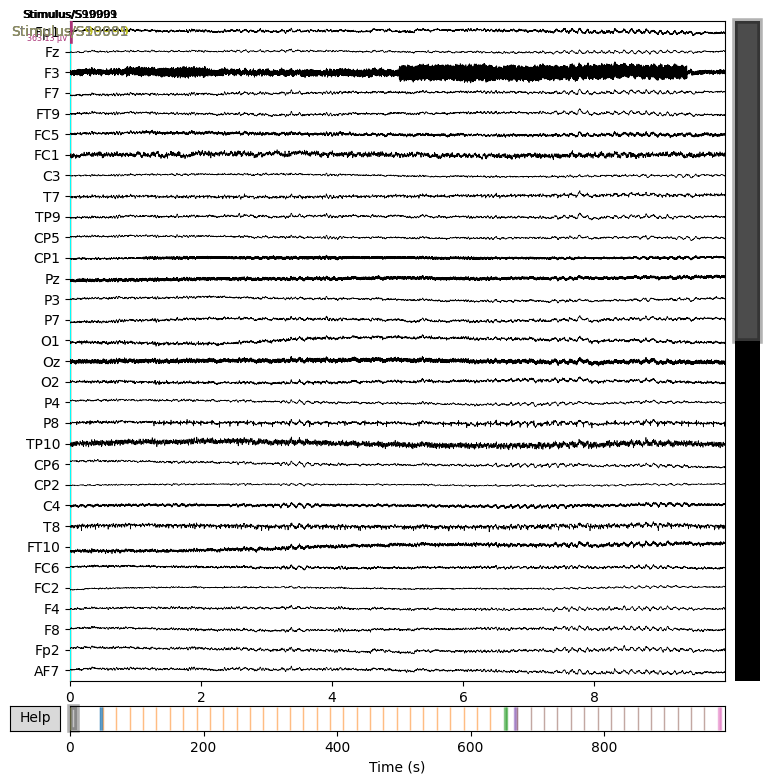

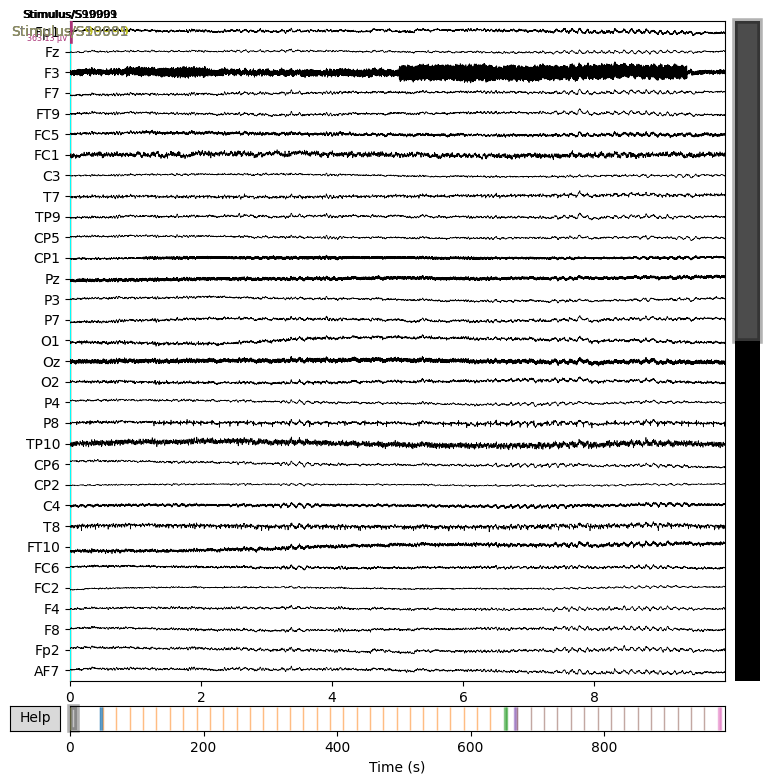

In [6]:

raw.plot(
    events=events,
    event_id=event_id,
    duration=10,
    n_channels=32,
    scalings="auto",
    show_scrollbars=True,
    block=True
)

S12 = smartphone-use onset

S13 = smartphone-use offset

S22 = video-viewing onset

S23 = video-viewing offset

In [7]:
# Load events file
events_file = Path("data/ds007537/sub-01/eeg/sub-01_task-phoneuse_events.tsv")
events_df = pd.read_csv(events_file, sep="\t")

# Keep only stimulus events and remove duplicated rows
stim_events = events_df[
    events_df["trial_type"].str.startswith("Stimulus", na=False)
].drop_duplicates(
    subset=["onset", "trial_type", "value", "sample"]
)

display(stim_events)

,onset,duration,trial_type,value,sample
4,44.547,0.0,Stimulus/S 11,11,44547
6,45.552,0.0,Stimulus/S 11,11,45552
8,46.552,0.0,Stimulus/S 11,11,46552
10,47.551,0.0,Stimulus/S 11,11,47551
12,48.551,0.0,Stimulus/S 11,11,48551
...,...,...,...,...,...
124,971.208,0.0,Stimulus/S 23,23,971208
126,972.223,0.0,Stimulus/S 23,23,972223
128,973.224,0.0,Stimulus/S 23,23,973224
130,974.224,0.0,Stimulus/S 23,23,974224


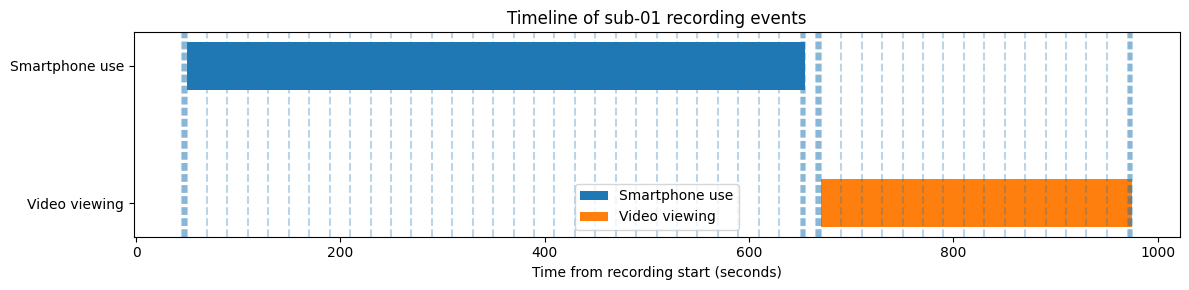

In [13]:
blocks = {
    "Smartphone use": (12, 13, 1),
    "Video viewing": (22, 23, 0)
}

fig, ax = plt.subplots(figsize=(12, 3))

for label, (start_code, end_code, y) in blocks.items():
    start = stim_events.loc[stim_events["value"] == start_code, "onset"].min()
    end = stim_events.loc[stim_events["value"] == end_code, "onset"].max()

    ax.barh(y, end - start, left=start, height=0.35, label=label)

for onset in stim_events["onset"]:
    ax.axvline(onset, linestyle="--", alpha=0.3)

ax.set_yticks([0, 1])
ax.set_yticklabels(["Video viewing", "Smartphone use"])
ax.set_xlabel("Time from recording start (seconds)")
ax.set_title("Timeline of sub-01 recording events")
ax.legend()

plt.tight_layout()
plt.show()